# 3 Layout Algebra

While CUTE layouts are only a subset of the space of all possible functions, they are capable of representing a strictly larger set of layout functions than the traditional flat-shape and flat-stride representations found in libraries like BLAS, `torch.tensor`, and `numpy.ndarray`.

Beyond their representational power, a key utility of CUTE layouts lies in their ability to be manipulated and combined to create new layouts. This is achieved through a core set of algebraic operations defined over layouts, which can be further used to construct higher-level operations.

In this section, we define layout homomorphisms -- operations that take CUTE layout(s) and produce a CUTE layout that satisfies some functional properties.

## 3.1 Concatenate

A layout can be expressed as the concatenation of its sublayouts,

$$L = S : D = (S_0, S_1, \ldots, S_n) : (D_0, D_1, \ldots, D_n) = (S_0 : D_0,\; S_1 : D_1,\; \ldots,\; S_n : D_n) = (L_0, L_1, \ldots, L_n)$$

such that

$$\forall\, c = (c_0, c_1, \ldots, c_n) \in \mathbb{Z}(L),\quad L(c) = L_0(c_0) + L_1(c_1) + \cdots + L_n(c_n). \tag{11}$$

In [1]:
from tensor_layouts import *
from tensor_layouts.viz import draw_layout

In [2]:
# A rank-2 layout: its two sublayouts are its modes
L = Layout((4, 8), (2, 8))
L0 = mode(L, 0)  # 4:2
L1 = mode(L, 1)  # 8:8
print(f"L  = {L}")
print(f"L0 = {L0}")
print(f"L1 = {L1}")
print()

# Verify Eq. (11): L(c0, c1) = L0(c0) + L1(c1)
for c0 in range(4):
    for c1 in range(8):
        assert L(c0, c1) == L0(c0) + L1(c1)
print("Verified: L(c0, c1) = L0(c0) + L1(c1) for all coordinates.")
print()

# Show a few examples
for c0, c1 in [(0, 0), (1, 0), (0, 1), (2, 3), (3, 7)]:
    print(f"  L({c0},{c1}) = {L(c0,c1):3d}  =  L0({c0}) + L1({c1})  =  {L0(c0)} + {L1(c1)}  =  {L0(c0)+L1(c1)}")

L  = (4, 8) : (2, 8)
L0 = 4 : 2
L1 = 8 : 8

Verified: L(c0, c1) = L0(c0) + L1(c1) for all coordinates.

  L(0,0) =   0  =  L0(0) + L1(0)  =  0 + 0  =  0
  L(1,0) =   2  =  L0(1) + L1(0)  =  2 + 0  =  2
  L(0,1) =   8  =  L0(0) + L1(1)  =  0 + 8  =  8
  L(2,3) =  28  =  L0(2) + L1(3)  =  4 + 24  =  28
  L(3,7) =  62  =  L0(3) + L1(7)  =  6 + 56  =  62


In [3]:
# The same property holds for hierarchical layouts
L_hier = Layout(((2, 3), 5), ((1, 6), 2))
L_hier_0 = mode(L_hier, 0)  # (2,3):(1,6)
L_hier_1 = mode(L_hier, 1)  # 5:2
print(f"L  = {L_hier}")
print(f"L0 = {L_hier_0}")
print(f"L1 = {L_hier_1}")
print()

# Verify with 1D coordinates on each mode
for c0 in range(size(L_hier_0)):
    for c1 in range(size(L_hier_1)):
        assert L_hier(c0, c1) == L_hier_0(c0) + L_hier_1(c1)
print("Verified for hierarchical layout: L(c0, c1) = L0(c0) + L1(c1)")

L  = ((2, 3), 5) : ((1, 6), 2)
L0 = (2, 3) : (1, 6)
L1 = 5 : 2

Verified for hierarchical layout: L(c0, c1) = L0(c0) + L1(c1)


In [4]:
# Concatenation also works in reverse: given sublayouts, we can build the full layout
A = Layout(4, 3)
B = Layout(6, 12)
AB = Layout(A, B)
print(f"A = {A}")
print(f"B = {B}")
print(f"Layout(A, B) = {AB}")
print()

# Verify the concatenation property
for c0 in range(size(A)):
    for c1 in range(size(B)):
        assert AB(c0, c1) == A(c0) + B(c1)
print("Verified: Layout(A, B)(c0, c1) = A(c0) + B(c1)")

A = 4 : 3
B = 6 : 12
Layout(A, B) = (4, 6) : (3, 12)

Verified: Layout(A, B)(c0, c1) = A(c0) + B(c1)


Full layout: (4, 8) : (2, 8)


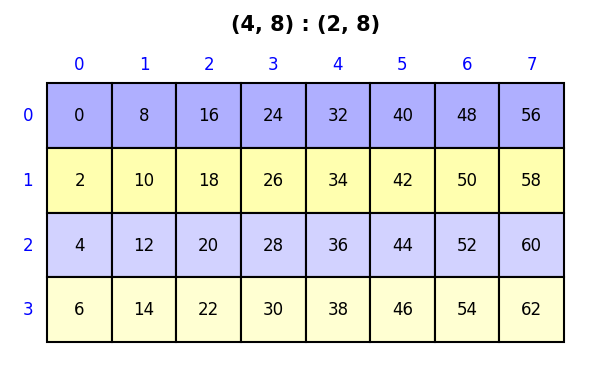


Mode 0 (rows): 4 : 2


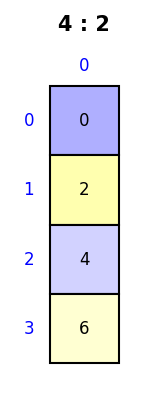


Mode 1 (cols): 8 : 8


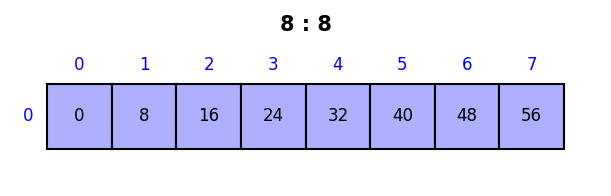

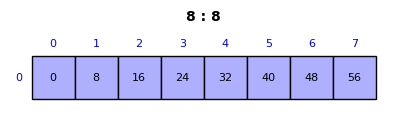

In [5]:
# Visualize: a layout and its sublayouts
print(f"Full layout: {L}")
draw_layout(L, colorize=True)

print(f"\nMode 0 (rows): {L0}")
draw_layout(L0, colorize=True, transpose=True)

print(f"\nMode 1 (cols): {L1}")
draw_layout(L1, colorize=True)

For concatenation admissibility, the functional property (11) implies that the codomain of all sublayouts must be contained in the same integer-semimodule. For instance, any two layouts with integer strides may be concatenated, but the layouts $4 : 2$ and $3 : e_0$ cannot be concatenated.

Noting that every sublayout of a layout is also a layout, it is useful to observe that any algebraic operation that manipulates a layout can also be applied to any individual sublayout. We often call these "by-mode operations," and every operation that is defined in this section (coalesce, composition, complement, logical divide, etc) can also be applied by-mode. This approach is expressed with the combinator

$$A \star \langle B, C \rangle = (A_0, A_1) \star \langle B, C \rangle = (A_0 \star B,\; A_1 \star C), \tag{12}$$

where the $\star$ is some operation on two layouts and the $\langle \rangle$ notation represents a tuple of layouts, distinguishing it from a concatenation of layouts.

In [6]:
# Demonstrate by-mode operations using coalesce as an example
# (This previews Section 3.2, but the by-mode combinator is defined here.)

A = Layout((2, (1, 6)), (1, (6, 2)))
print(f"A = {A}")
print(f"coalesce(A) = {coalesce(A)}")
print()

# By-mode coalesce: apply coalesce to each mode independently
A0 = mode(A, 0)
A1 = mode(A, 1)
print(f"A0 = {A0}  ->  coalesce(A0) = {coalesce(A0)}")
print(f"A1 = {A1}  ->  coalesce(A1) = {coalesce(A1)}")
print()

# Reconstruct from coalesced modes
A_bymode = Layout(coalesce(A0), coalesce(A1))
print(f"By-mode coalesced: {A_bymode}")
print()

# The full coalesce merges everything to 12:1,
# but by-mode preserves the rank-2 structure: (2,6):(1,2)
# Both are functionally equivalent over their respective coordinate spaces
for i in range(size(A)):
    assert A(i) == coalesce(A)(i)
    assert A(i) == A_bymode(i)
print("All three are functionally equivalent over 1D coordinates.")

A = (2, (1, 6)) : (1, (6, 2))
coalesce(A) = 12 : 1

A0 = 2 : 1  ->  coalesce(A0) = 2 : 1
A1 = (1, 6) : (6, 2)  ->  coalesce(A1) = 6 : 2

By-mode coalesced: (2, 6) : (1, 2)

All three are functionally equivalent over 1D coordinates.


In [7]:
# Another by-mode example from the paper:
# ((4,3), 5) : ((15,1), 3) coalesces to (4, 15):(15, 1)
# but by-mode coalesce leaves it unchanged

B = Layout(((4, 3), 5), ((15, 1), 3))
print(f"B = {B}")
print(f"coalesce(B) = {coalesce(B)}")
print()

B0, B1 = mode(B, 0), mode(B, 1)
print(f"B0 = {B0}  ->  coalesce(B0) = {coalesce(B0)}")
print(f"B1 = {B1}  ->  coalesce(B1) = {coalesce(B1)}")

B_bymode = Layout(coalesce(B0), coalesce(B1))
print(f"By-mode coalesced: {B_bymode}")
print()

# By-mode coalesce preserves the structure because each mode is already minimal
for i in range(size(B)):
    assert B(i) == coalesce(B)(i)
print("Functionally equivalent.")

B = ((4, 3), 5) : ((15, 1), 3)
coalesce(B) = (4, 15) : (15, 1)

B0 = (4, 3) : (15, 1)  ->  coalesce(B0) = (4, 3) : (15, 1)
B1 = 5 : 3  ->  coalesce(B1) = 5 : 3
By-mode coalesced: ((4, 3), 5) : ((15, 1), 3)

Functionally equivalent.
